# Sprint 5 - Business Value

Este notebook implementa PB-16 reforzado: matriz de confusion por umbral, costo sin modelo, costo con modelo, ahorro neto, ROI, valor por 1000 URLs, escenarios de sensibilidad y justificacion del umbral operativo para deteccion de phishing.


In [ ]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation import (
    BUSINESS_VALUE_SCENARIOS,
    DEFAULT_BUSINESS_ASSUMPTIONS,
    evaluate_business_scenarios,
    evaluate_threshold,
    gain_curve,
    phishing_probability,
    threshold_search,
)


## 1. Cargar modelo final y test set

In [34]:
TARGET_COL = 'Result'
test_df = pd.read_csv('../data/processed/test.csv')
X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

model = joblib.load('../models/final_model.pkl')
y_proba_phishing = phishing_probability(model, X_test)

print(f'Test set: {X_test.shape}')
print(f'Distribucion: {dict(y_test.value_counts().sort_index())}')


Test set: (1170, 37)
Distribucion: {-1: np.int64(604), 1: np.int64(566)}


C:\Users\RyzFor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 2. Supuestos economicos y formula

KPI economico principal: **ahorro neto esperado**.

Formula usada:

- `costo_sin_modelo = phishing_reales * costo_FN`
- `alertas = TP + FP`
- `costo_operativo_total = alertas * costo_revision + total_urls * costo_operativo_por_url`
- `costo_con_modelo = FN*costo_FN + FP*costo_FP + alertas*costo_revision + total_urls*costo_operativo_por_url`
- `ahorro_neto = costo_sin_modelo - costo_con_modelo`
- `ROI = ahorro_neto / costo_operativo_total`
- `valor_por_1000_URLs = ahorro_neto / total_urls * 1000`

En phishing, el falso negativo es el error critico porque deja pasar una URL maliciosa. El falso positivo tiene menor costo porque representa una falsa alarma o revision manual.


In [ ]:
assumptions = DEFAULT_BUSINESS_ASSUMPTIONS.copy()
pd.DataFrame([assumptions])


In [ ]:
reference = evaluate_threshold(y_test, y_proba_phishing, threshold=0.50, assumptions=assumptions)
pd.DataFrame([reference])


## 3. Busqueda de umbral operativo

Se evalua el rango 0.01 a 0.99. El umbral recomendado maximiza `ahorro_neto` y debe mantener el recall minimo definido en los supuestos. El umbral 0.50 se conserva como referencia tecnica, no como decision economica por defecto.


In [ ]:
threshold_results, best = threshold_search(
    y_test,
    y_proba_phishing,
    assumptions=assumptions,
    start=0.01,
    stop=0.99,
    step=0.01,
    minimum_recall=assumptions['minimum_recall'],
)

threshold_results.to_csv('../reports/business_value_thresholds.csv', index=False)
comparison = pd.DataFrame([reference, best], index=['umbral_0_50', 'umbral_recomendado'])
comparison[[
    'threshold', 'tn', 'fp', 'fn', 'tp', 'recall', 'precision',
    'cost_without_model', 'cost_with_model', 'net_savings', 'roi',
    'value_per_1000_urls', 'annual_net_savings'
]]


In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(threshold_results['threshold'], threshold_results['net_savings'], color='#1565c0', label='Ahorro neto')
ax1.axvline(best['threshold'], color='#d32f2f', linestyle='--', label=f"Umbral recomendado={best['threshold']:.2f}")
ax1.axvline(0.50, color='#616161', linestyle=':', label='Referencia=0.50')
ax1.set_title('Ahorro neto por umbral de decision')
ax1.set_xlabel('Umbral de phishing')
ax1.set_ylabel('Ahorro neto en test (USD)')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(threshold_results['threshold'], threshold_results['recall'], color='#2e7d32', alpha=0.65, label='Recall phishing')
ax2.axhline(assumptions['minimum_recall'], color='#2e7d32', linestyle=':', alpha=0.65, label='Recall minimo')
ax2.set_ylabel('Recall phishing')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower left')
plt.tight_layout()
plt.savefig('../reports/figures/business_value_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Escenarios de sensibilidad

Se comparan escenarios conservador, base y severo variando principalmente el costo del falso negativo y el recall minimo requerido.


In [ ]:
scenario_results = evaluate_business_scenarios(
    y_test,
    y_proba_phishing,
    scenarios=BUSINESS_VALUE_SCENARIOS,
    start=0.01,
    stop=0.99,
    step=0.01,
)
scenario_results.to_csv('../reports/business_value_scenarios.csv', index=False)
scenario_results


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#6a994e', '#1565c0', '#c62828']
ax.bar(scenario_results['scenario'], scenario_results['annual_net_savings'], color=colors)
ax.set_title('Ahorro neto anual por escenario')
ax.set_xlabel('Escenario')
ax.set_ylabel('Ahorro neto anual estimado (USD)')
for idx, row in scenario_results.iterrows():
    ax.text(
        idx,
        row['annual_net_savings'],
        f"t={row['recommended_threshold']:.2f}\nrecall={row['recommended_recall']:.3f}",
        ha='center',
        va='bottom',
        fontsize=9,
    )
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/business_value_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Curva de ganancia y lift


In [39]:
gain = gain_curve(y_test, y_proba_phishing)
gain.to_csv('../reports/gain_curve.csv', index=False)
gain.head()


,contacted_share,captured_share,lift
0,0.000855,0.001656,1.937086
1,0.001709,0.003311,1.937086
2,0.002564,0.004967,1.937086
3,0.003419,0.006623,1.937086
4,0.004274,0.008278,1.937086


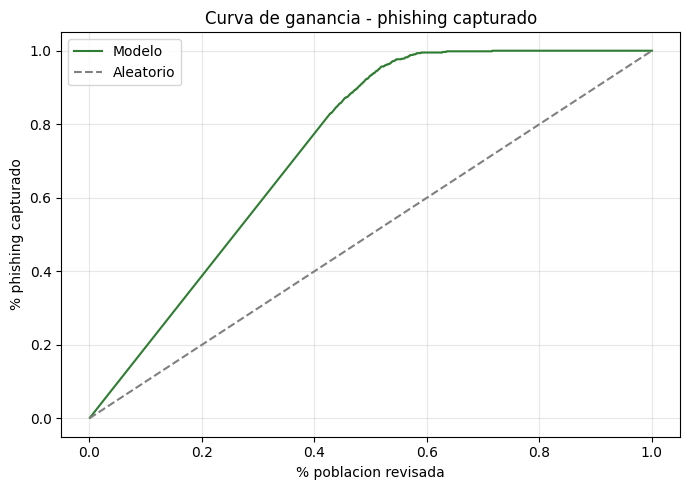

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gain['contacted_share'], gain['captured_share'], label='Modelo', color='#2e7d32')
ax.plot([0, 1], [0, 1], '--', label='Aleatorio', color='gray')
ax.set_title('Curva de ganancia - phishing capturado')
ax.set_xlabel('% poblacion revisada')
ax.set_ylabel('% phishing capturado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/gain_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Interpretacion ejecutiva


In [ ]:
summary = pd.DataFrame([
    {'item': 'kpi_economico_principal', 'value': 'ahorro_neto_esperado'},
    {'item': 'kpi_tecnico_soporte', 'value': 'recall_phishing'},
    {'item': 'umbral_referencia', 'value': reference['threshold']},
    {'item': 'umbral_recomendado', 'value': best['threshold']},
    {'item': 'recall_minimo', 'value': assumptions['minimum_recall']},
    {'item': 'fn_referencia', 'value': reference['fn']},
    {'item': 'fp_referencia', 'value': reference['fp']},
    {'item': 'recall_referencia', 'value': reference['recall']},
    {'item': 'costo_sin_modelo_referencia_usd', 'value': reference['cost_without_model']},
    {'item': 'costo_con_modelo_referencia_usd', 'value': reference['cost_with_model']},
    {'item': 'ahorro_neto_referencia_usd', 'value': reference['net_savings']},
    {'item': 'roi_referencia', 'value': reference['roi']},
    {'item': 'valor_por_1000_urls_referencia_usd', 'value': reference['value_per_1000_urls']},
    {'item': 'ahorro_neto_anual_referencia_usd', 'value': reference['annual_net_savings']},
    {'item': 'fn_recomendado', 'value': best['fn']},
    {'item': 'fp_recomendado', 'value': best['fp']},
    {'item': 'recall_recomendado', 'value': best['recall']},
    {'item': 'costo_sin_modelo_recomendado_usd', 'value': best['cost_without_model']},
    {'item': 'costo_con_modelo_recomendado_usd', 'value': best['cost_with_model']},
    {'item': 'ahorro_neto_recomendado_usd', 'value': best['net_savings']},
    {'item': 'roi_recomendado', 'value': best['roi']},
    {'item': 'valor_por_1000_urls_recomendado_usd', 'value': best['value_per_1000_urls']},
    {'item': 'ahorro_neto_anual_recomendado_usd', 'value': best['annual_net_savings']},
    {'item': 'ahorro_incremental_vs_050_usd', 'value': best['net_savings'] - reference['net_savings']},
    {'item': 'ahorro_incremental_anual_vs_050_usd', 'value': best['annual_net_savings'] - reference['annual_net_savings']},
    {'item': 'annual_value_reference_usd', 'value': reference['annual_net_savings']},
    {'item': 'annual_value_optimal_usd', 'value': best['annual_net_savings']},
])
summary.to_csv('../reports/business_value_summary.csv', index=False)
summary
